In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Ensure plots appear in the notebook
%matplotlib inline

In [89]:
# Load the dataset.
date_cols = ['Application Date', 'Offered Date', 'Confirmation Date', 'Arrived Date', 'Cancellation Date']
studygroup= pd.read_excel('sg_studentdata_cleaned.xlsx', parse_dates=date_cols)

# Quick look at the data structure.
print(studygroup.info())
studygroup.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71754 entries, 0 to 71753
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Centre             71754 non-null  object        
 1   Programme          71754 non-null  object        
 2   Area               71754 non-null  object        
 3   Region             71754 non-null  object        
 4   Sub Region         70946 non-null  object        
 5   Country            71754 non-null  object        
 6   Branch URN         71754 non-null  object        
 7   Group URN          71754 non-null  object        
 8   Lead Source        71754 non-null  object        
 9   Student ID         71754 non-null  int64         
 10  Booking ID         71754 non-null  int64         
 11  Nationality        71754 non-null  object        
 12  IntakeYear         71754 non-null  int64         
 13  IntakeQuarter      71754 non-null  int64         
 14  Applic

,Centre,Programme,Area,Region,Sub Region,Country,Branch URN,Group URN,Lead Source,Student ID,...,Confirmation Date,Arrived Date,Cancellation Date,Completed,Progressed,Registered,Tuition Fees,Net Value,Discount,Discount Type
0,Leeds,Diploma,China,E C1 China,E China,Shanghai,C15433,C15301,Standard Agent Booking,2739037,...,NaT,NaT,2022-07-08,NaN,NaN,NaN,19500.0,19500.0,0.0,NaN
1,Cardiff,Foundation,UK EU & Americas,UK & W Europe,UK & W Europe,UK,U19750,U19750,Sponsor,2742709,...,NaT,NaT,2023-09-13,NaN,NaN,NaN,20500.0,20500.0,0.0,NaN
2,Sheffield,Foundation,UK EU & Americas,UK & W Europe,UK & W Europe,UK,U19750,U19750,Sponsor,2742709,...,NaT,NaT,2023-09-13,NaN,NaN,NaN,24900.0,24900.0,0.0,NaN
3,Durham,Pre Masters,China,N C2 China,N China,Beijing,I1808,I20278,Standard Agent Booking,2690785,...,NaT,NaT,2024-01-03,NaN,NaN,NaN,22300.0,22300.0,0.0,NaN
4,Durham,Foundation,ANZ & N Asia,North Asia,Japan,Japan,B12274,E30277,Standard Agent Booking,2732702,...,NaT,NaT,2023-03-22,NaN,NaN,NaN,22000.0,22000.0,0.0,NaN


In [90]:
# Check for missing values in key columns.
missing_values = studygroup.isnull().sum()
print(missing_values)

Centre                   0
Programme                0
Area                     0
Region                   0
Sub Region             808
Country                  0
Branch URN               0
Group URN                0
Lead Source              0
Student ID               0
Booking ID               0
Nationality              0
IntakeYear               0
IntakeQuarter            0
Application Date         0
Offered Date         19862
Confirmation Date    65318
Arrived Date         67666
Cancellation Date     4747
Completed            67666
Progressed           68059
Registered           68500
Tuition Fees             0
Net Value                0
Discount                 0
Discount Type        69270
dtype: int64


In [91]:
# Check the number of duplicate student IDs.
duplicate_count = studygroup.duplicated(subset=['Student ID']).sum()
print("Number of duplicate Student IDs:", duplicate_count)

Number of duplicate Student IDs: 34516


In [92]:
# Create binary flags for stages in the conversion funnel.
studygroup['Got_Offer'] = studygroup['Offered Date'].notnull()
studygroup['Confirmed'] = studygroup['Confirmation Date'].notnull()
studygroup['Arrived'] = studygroup['Arrived Date'].notnull()
studygroup['Cancelled'] = studygroup['Cancellation Date'].notnull()

In [93]:
# Create dummy variables for 'Completed' column.
completed_dummies = pd.get_dummies(studygroup['Completed'], prefix='Completed', dummy_na=True)

# Concatenate the dummy variables with the original DataFrame.
studygroup= pd.concat([studygroup, completed_dummies], axis=1)

# Convert 'Progressed' and 'Registered' columns to integers.
studygroup['Progressed'] = studygroup['Progressed'].apply(lambda x: 1 if x == 'Yes' else 0)
studygroup['Registered'] = studygroup['Registered'].apply(lambda x: 1 if x == 'Yes' else 0)

# Drop the original 'Completed' column if no longer needed.
studygroup.drop(columns=['Completed'], inplace=True)

In [94]:
# Summarising the Conversion Funnel.
total_applications = studygroup['Student ID'].nunique()
total_offers = studygroup['Got_Offer'].sum()
total_confirmations = studygroup['Confirmed'].sum()
total_arrivals = studygroup['Arrived'].sum()
total_registrations = studygroup['Registered'].sum()

print("Total Unique Students (Applications):", total_applications)
print("Total Offers Issued:", total_offers)
print("Total Confirmations:", total_confirmations)
print("Total Arrivals:", total_arrivals)
print("Total Registrations:", total_registrations)


Total Unique Students (Applications): 37238
Total Offers Issued: 51892
Total Confirmations: 6436
Total Arrivals: 4088
Total Registrations: 2620


In [95]:
# Calculate percentages at each stage.
offer_conversion = total_offers / total_applications * 100
confirmation_conversion = total_confirmations / total_applications * 100
arrival_conversion = total_arrivals / total_applications * 100
registration_conversion = total_registrations / total_applications * 100

print(f"Offer Conversion Rate: {offer_conversion:.1f}%")
print(f"Confirmation Conversion Rate: {confirmation_conversion:.1f}%")
print(f"Arrival Conversion Rate: {arrival_conversion:.1f}%")
print(f"Registration Conversion Rate: {registration_conversion:.1f}%")

Offer Conversion Rate: 139.4%
Confirmation Conversion Rate: 17.3%
Arrival Conversion Rate: 11.0%
Registration Conversion Rate: 7.0%


Lead Source
APD                       23.232323
Sponsor                    2.044964
Standard Agent Booking     4.069112
Name: Registered, dtype: float64


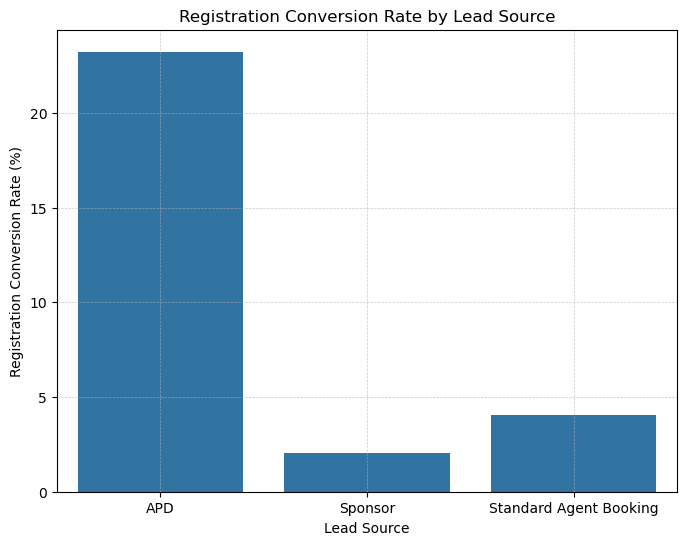

In [96]:
# Conversion by Lead Source.
conversion_by_lead = studygroup.groupby('Lead Source')['Registered'].mean() * 100
print(conversion_by_lead)

plt.figure(figsize=(8,6))
sns.barplot(x=conversion_by_lead.index, y=conversion_by_lead.values)
plt.xlabel('Lead Source')
plt.ylabel('Registration Conversion Rate (%)')
plt.title('Registration Conversion Rate by Lead Source')
plt.grid(axis='both', linestyle='--', alpha=0.7, linewidth=0.5)
plt.show()

In [97]:
# Group by IntakeYear and IntakeQuarter to see conversion trends
funnel_by_intake = studygroup.groupby(['IntakeYear', 'IntakeQuarter']).agg({
    'Student ID': pd.Series.nunique,
    'Offered Date': lambda x: x.notnull().sum(),
    'Confirmation Date': lambda x: x.notnull().sum(),
    'Arrived Date': lambda x: x.notnull().sum(),
    'Registered': lambda x: x.sum()
}).rename(columns={'Student ID': 'Total Applications'})

print(funnel_by_intake)

                          Total Applications  Offered Date  Confirmation Date  \
IntakeYear IntakeQuarter                                                        
2023       3                           25071         31275               3501   
           4                            9133          8450               1126   
2024       1                            9639         10922               1641   
           2                            1462          1245                168   

                          Arrived Date  Registered  
IntakeYear IntakeQuarter                            
2023       3                      2313        1624  
           4                       707         381  
2024       1                      1034         590  
           2                        34          25  


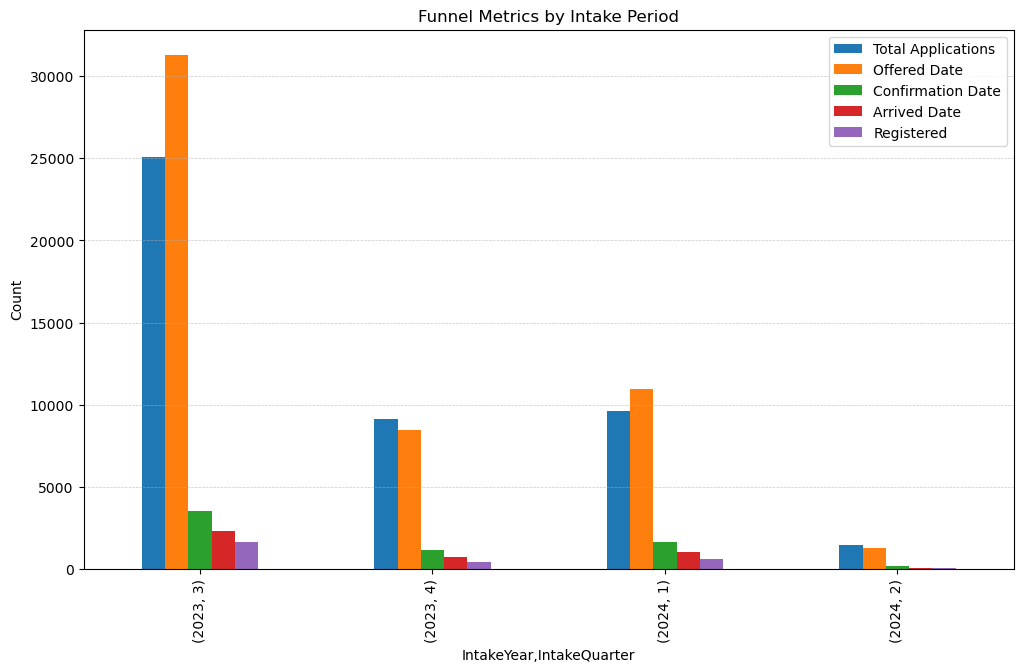

In [98]:
# Visualise the funnel per intake period.
funnel_by_intake.plot(kind='bar', figsize=(12,7))
plt.ylabel('Count')
plt.title('Funnel Metrics by Intake Period')
plt.grid(axis='y', linestyle='--', alpha=0.7, linewidth=0.5)
plt.show()

In [99]:
# Aggregate conversion flags at the student level.
student_agg = studygroup.groupby('Student ID').agg({
    'Got_Offer': 'max',
    'Confirmed': 'max',
    'Arrived': 'max',
    'Registered': 'max'
}).reset_index()

# Calculate the total number of unique students.
total_students = student_agg.shape[0]
offers_student = student_agg['Got_Offer'].sum()
confirmations_student = student_agg['Confirmed'].sum()
arrivals_student = student_agg['Arrived'].sum()
registrations_student = student_agg['Registered'].sum()

print("Total Unique Students:", total_students)
print("Student-Level Offers Issued:", offers_student)
print("Student-Level Confirmations:", confirmations_student)
print("Student-Level Arrivals:", arrivals_student)
print("Student-Level Registrations:", registrations_student)

Total Unique Students: 37238
Student-Level Offers Issued: 29516
Student-Level Confirmations: 5728
Student-Level Arrivals: 4086
Student-Level Registrations: 2618


C:\Users\Emmanuel Wagaba\AppData\Local\Temp\ipykernel_3648\1424123359.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Stage', y='Count', data=funnel_data, palette='viridis')


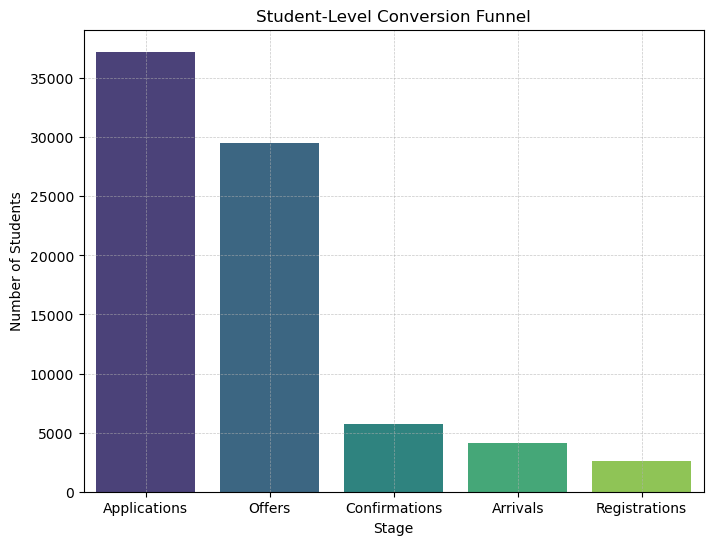

In [100]:
# Create a DataFrame for plotting.
funnel_data = pd.DataFrame({
    'Stage': ['Applications', 'Offers', 'Confirmations', 'Arrivals', 'Registrations'],
    'Count': [total_students, offers_student, confirmations_student, arrivals_student, registrations_student]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Stage', y='Count', data=funnel_data, palette='viridis')
plt.title('Student-Level Conversion Funnel')
plt.ylabel('Number of Students')
plt.grid(axis='both', linestyle='--', alpha=0.7, linewidth=0.5)
plt.show()

In [101]:
# Aggregate the data at the student level.
student_df = studygroup.groupby('Student ID').agg({
    'Group URN': 'first',
    'Discount': 'max',
    'Centre': 'first',
    'Programme': 'first',
    'Area': 'first',
    'Registered': 'max',
    'Nationality': 'first',
    'Tuition Fees': 'mean',
    'Net Value': 'mean',
    'Lead Source': lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0]
}).reset_index()

# Create discount bins using the same bin edges and labels.
bins = [-np.inf, 0, 1000, 2000, 3000, 4000, 5000, np.inf]
labels = ['0', '0-1k', '1k-2k', '2k-3k', '3k-4k', '4k-5k', '>5k']
student_df['Discount_Bin'] = pd.cut(student_df['Discount'], bins=bins, labels=labels)

# Calculate the conversion rate within each discount bin at the student level.
conversion_by_discount_student = student_df.groupby('Discount_Bin')['Registered'].mean() * 100
print(conversion_by_discount_student)

Discount_Bin
0         4.732711
0-1k     29.452055
1k-2k    33.636364
2k-3k    46.749226
3k-4k    54.222222
4k-5k    50.632911
>5k      44.578313
Name: Registered, dtype: float64


C:\Users\Emmanuel Wagaba\AppData\Local\Temp\ipykernel_3648\2107035842.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conversion_by_discount_student = student_df.groupby('Discount_Bin')['Registered'].mean() * 100


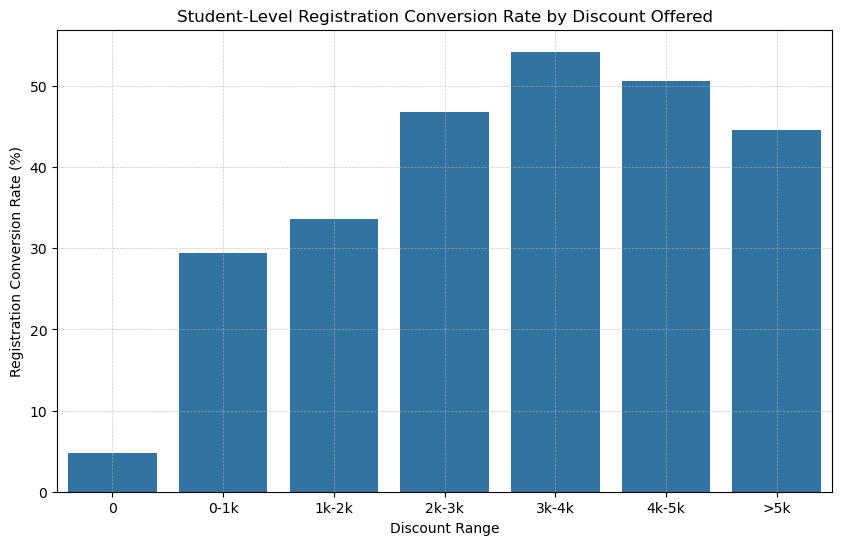

In [102]:
# Plot the conversion rates by discount bin.
plt.figure(figsize=(10,6))
sns.barplot(x=conversion_by_discount_student.index, y=conversion_by_discount_student.values)
plt.xlabel('Discount Range')
plt.ylabel('Registration Conversion Rate (%)')
plt.grid(axis='both', linestyle='--', alpha=0.7, linewidth=0.5)
plt.title('Student-Level Registration Conversion Rate by Discount Offered')
plt.show()

Lead Source
APD                       35.937500
Sponsor                    4.650200
Standard Agent Booking     7.545026
Name: Registered, dtype: float64


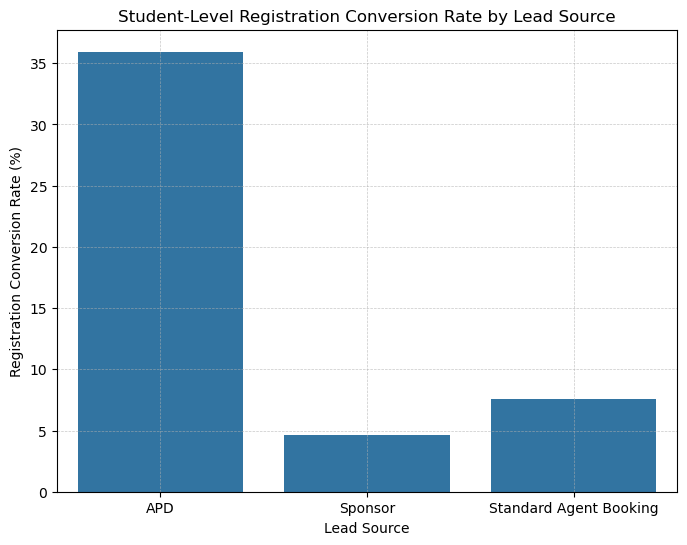

In [103]:
# Calculate the registration conversion rate by Lead Source.
conversion_by_lead_student = student_df.groupby('Lead Source')['Registered'].mean() * 100
print(conversion_by_lead_student)

# Plot the conversion rates by Lead Source.
plt.figure(figsize=(8,6))
sns.barplot(x=conversion_by_lead_student.index, y=conversion_by_lead_student.values)
plt.xlabel('Lead Source')
plt.ylabel('Registration Conversion Rate (%)')
plt.grid(axis='both', linestyle='--', alpha=0.7, linewidth=0.5)
plt.title('Student-Level Registration Conversion Rate by Lead Source')
plt.show()

In [104]:
# Create a features DataFrame for segmentation.
features = student_df[['Discount', 'Tuition Fees', 'Net Value']].copy()

# Fill missing values if.
features.fillna(0, inplace=True)

# Standardize the features.
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

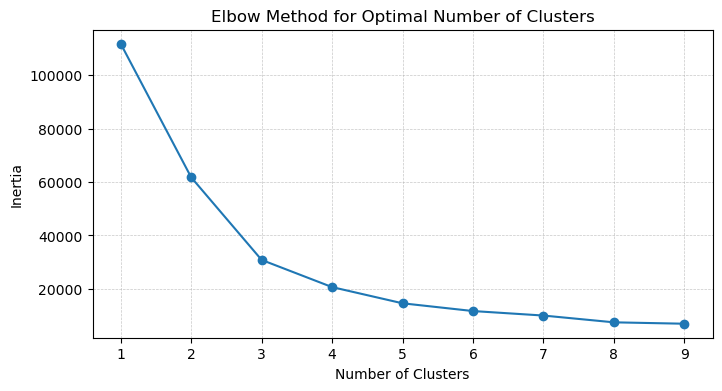

In [105]:
# Use the elbow method to decide on the optimal number of clusters.
ss = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    ss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 10), ss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.grid(axis='both', linestyle='--', alpha=0.7, linewidth=0.5)
plt.show()

In [106]:
# The elbow suggests 4 clusters.
optimal_clusters = 4
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
student_df['Cluster'] = kmeans.fit_predict(scaled_features)

# Check the sizes of the clusters.
print(student_df['Cluster'].value_counts().sort_index())

Cluster
0    10227
1     7560
2     1359
3    18092
Name: count, dtype: int64


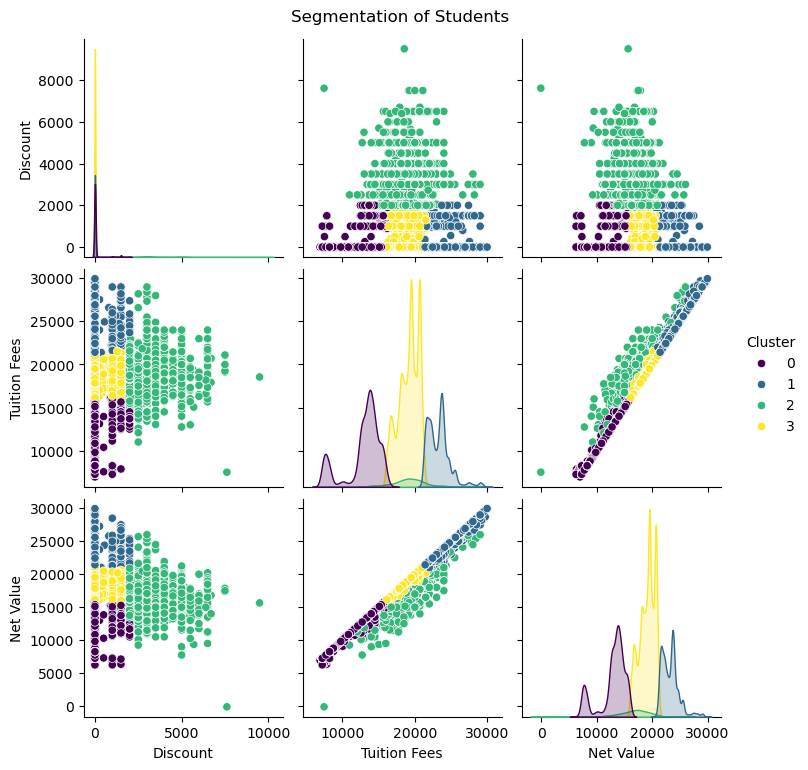

Cluster Centers (in original scale):
[[5.35402332e+01 1.29487732e+04 1.28885915e+04]
 [2.19612126e+01 2.32702619e+04 2.31939578e+04]
 [3.61798087e+03 1.91938275e+04 1.69277457e+04]
 [2.96341187e+01 1.91125102e+04 1.90551230e+04]]


In [107]:
# Visualise the clusters using a pairplot.
sns.pairplot(student_df, vars=['Discount', 'Tuition Fees', 'Net Value'], hue='Cluster', palette='viridis')
plt.suptitle('Segmentation of Students', y=1.02)
plt.show()

# Look at the cluster centers (in the original scale).
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
print("Cluster Centers (in original scale):")
print(cluster_centers)

In [108]:
# Cross-tabulation for Nationality.
nationality_ct = pd.crosstab(student_df['Cluster'], student_df['Nationality'], normalize='index')
nationality_ct

Nationality,Afghan,Albanian,Algerian,American,American Samoan,Angolan,Antiguan,Argentine,Armenian,Australian,...,Ugandan,Ukrainian,Uruguayan,Uzbek,Vanuatu,Venezuelan,Vietnamese,Yemeni,Zambian,Zimbabwean
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.008311,0.000196,0.011440,0.001173,0.000000,0.000684,0.000196,0.000098,0.000098,0.000098,...,0.002249,0.000391,0.000000,0.002053,0.000000,0.000196,0.005476,0.002249,0.000880,0.002542
1,0.001058,0.000397,0.001984,0.002910,0.000132,0.000397,0.000000,0.000132,0.000132,0.000132,...,0.001587,0.000397,0.000000,0.001190,0.000000,0.000397,0.002513,0.000265,0.000529,0.001190
2,0.000000,0.000000,0.014717,0.005151,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.006623,0.000000,0.004415,0.000000,0.001472,0.011773,0.000000,0.000000,0.000000
3,0.002708,0.000940,0.004035,0.004588,0.000000,0.001050,0.000166,0.000000,0.000166,0.000884,...,0.001879,0.001050,0.000111,0.001990,0.000055,0.000332,0.002929,0.001161,0.000663,0.002432


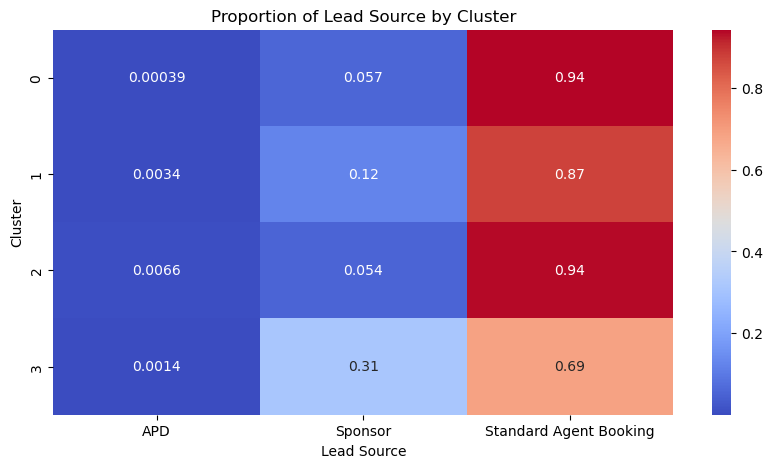

In [109]:
# Repeated for other demographic variables.
# For instance, for Lead Source:
lead_source_ct = pd.crosstab(student_df['Cluster'], student_df['Lead Source'], normalize='index')
plt.figure(figsize=(10, 5))
sns.heatmap(lead_source_ct, annot=True, cmap='coolwarm')
plt.title('Proportion of Lead Source by Cluster')
plt.xlabel('Lead Source')
plt.ylabel('Cluster')
plt.show()

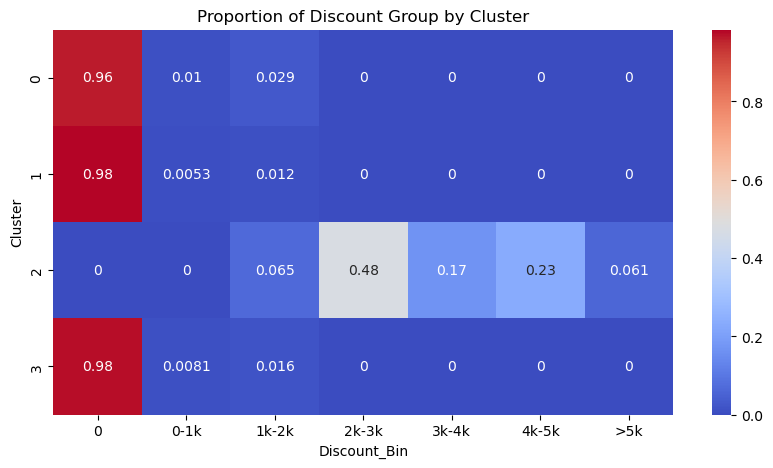

In [110]:
# For Discount Group:
discount_ct = pd.crosstab(student_df['Cluster'], student_df['Discount_Bin'], normalize='index')
plt.figure(figsize=(10, 5))
sns.heatmap(discount_ct, annot=True, cmap='coolwarm')
plt.title('Proportion of Discount Group by Cluster')
plt.xlabel('Discount_Bin')
plt.ylabel('Cluster')
plt.show()

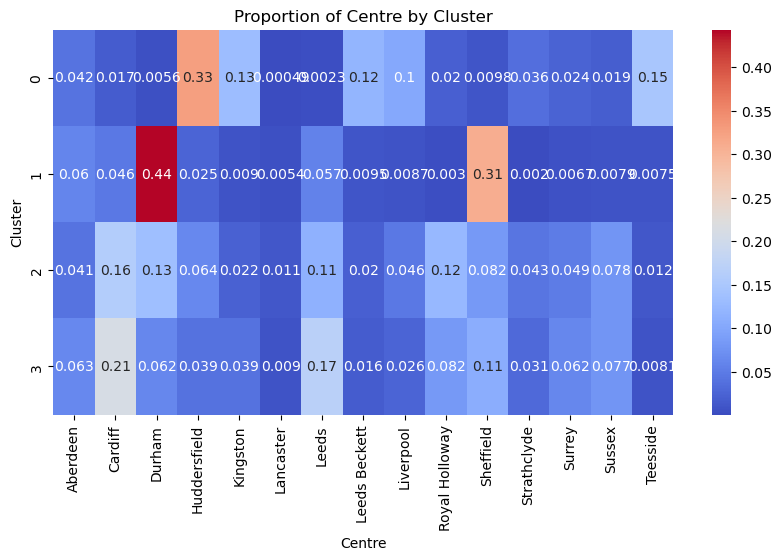

In [111]:
# For Centre:
centre_ct = pd.crosstab(student_df['Cluster'], student_df['Centre'], normalize='index')
plt.figure(figsize=(10, 5))
sns.heatmap(centre_ct, annot=True, cmap='coolwarm')
plt.title('Proportion of Centre by Cluster')
plt.xlabel('Centre')
plt.ylabel('Cluster')
plt.show()

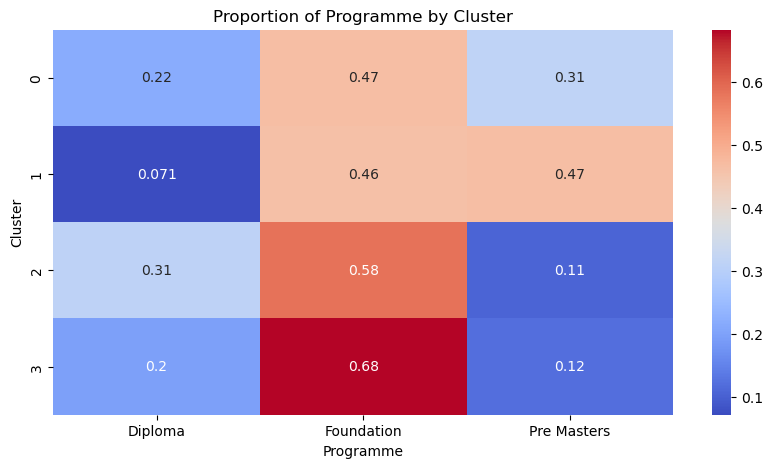

In [112]:
# For Programme:
programme_ct = pd.crosstab(student_df['Cluster'], student_df['Programme'], normalize='index')
plt.figure(figsize=(10, 5))
sns.heatmap(programme_ct, annot=True, cmap='coolwarm')
plt.title('Proportion of Programme by Cluster')
plt.xlabel('Programme')
plt.ylabel('Cluster')
plt.show()

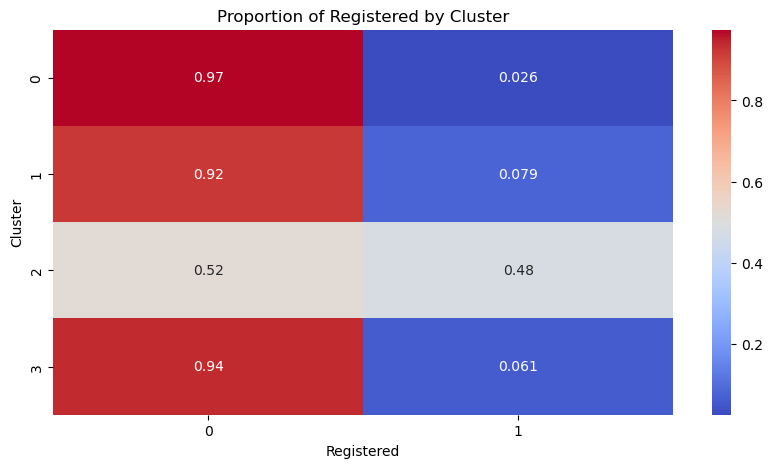

In [114]:
# For Registered:
registered_ct = pd.crosstab(student_df['Cluster'], student_df['Registered'], normalize='index')
plt.figure(figsize=(10, 5))
sns.heatmap(registered_ct, annot=True, cmap='coolwarm')
plt.title('Proportion of Registered by Cluster')
plt.xlabel('Registered')
plt.ylabel('Cluster')
plt.show()